# UNet-1L vs UNet-2L vs DB-Fast vs CNN vs MaskedCNN
## All with Coords, Train N=16, Eval to N=64

**Motivation:** 1-level UNet may be too shallow — only one pooling step limits
how much global context is captured. A 2-level UNet compresses twice,
giving a much smaller bottleneck and stronger multi-scale representation.

**UNet-1L (train N=16):**
```
16×16 → pool → 8×8 (bottleneck) → upsample → 16×16
```

**UNet-2L (train N=16):**
```
16×16 → pool → 8×8 → pool → 4×4 (bottleneck) → upsample → 8×8 → upsample → 16×16
```

**At OOD grids both UNets scale:**
```
N=64:  UNet-1L bottleneck=32×32,  UNet-2L bottleneck=16×16
```
UNet-2L always has a 4× smaller bottleneck → forces stronger compression
→ should learn more global, resolution-agnostic features.

**Five models, matched params (~593k), all with (x,y) coords:**

| Model | Structure | Bottleneck at N=16 | Bottleneck at N=64 |
|---|---|---|---|
| CNN | flat, free 3×3 | — | — |
| MaskedCNN | flat, ring mask | — | — |
| UNet-1L | 1 pool level | 8×8 | 32×32 |
| UNet-2L | 2 pool levels | 4×4 | 16×16 |
| DB-Fast | flat, edge+tri mask | — | — |


In [ ]:
import math, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from scipy.sparse import diags, eye
from scipy.sparse.linalg import spsolve

def set_seed(seed=4):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)

set_seed(6)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)


Device: cuda


## 1) Dataset


In [ ]:
D, SIGMA = 0.01, 1.0
print(f'D={D}, sigma={SIGMA}, decay length={math.sqrt(D/SIGMA):.3f}')

def build_rd_matrix(N, D=0.01, sigma=1.0):
    h=1./(N+1); n=N*N
    d0=-4.*np.ones(n); d1=np.ones(n-1); dN=np.ones(n-N)
    for i in range(1,N): d1[i*N-1]=0.
    L=diags([d0,d1,d1,dN,dN],[0,1,-1,N,-N],format='csr')/(h**2)
    return -D*L+sigma*eye(n,format='csr')

def solve_rd(f_flat, N, D=0.01, sigma=1.0):
    return spsolve(build_rd_matrix(N,D,sigma), f_flat)

def random_source_term(N, n_modes=4):
    h=1./(N+1); xs=np.arange(1,N+1)*h; ys=np.arange(1,N+1)*h
    X,Y=np.meshgrid(xs,ys); f=np.zeros((N,N))
    for _ in range(n_modes):
        cx,cy=np.random.uniform(0.1,0.9),np.random.uniform(0.1,0.9)
        amp=np.random.randn(); w=np.random.uniform(0.05,0.2)
        f+=amp*np.exp(-((X-cx)**2+(Y-cy)**2)/(2*w**2))
    return f

def make_rd_dataset(num_samples, N, D=0.01, sigma=1.0):
    h=1./(N+1); xs=np.arange(1,N+1)*h; ys=np.arange(1,N+1)*h
    X,Y=np.meshgrid(xs,ys)
    coords_t=torch.tensor(
        np.stack([X.flatten(),Y.flatten()],axis=-1),dtype=torch.float32)
    ds=[]
    for _ in range(num_samples):
        f=random_source_term(N); u=solve_rd(f.flatten(),N,D,sigma)
        u_std=max(u.std(),1e-8)
        ds.append((
            torch.tensor(f.flatten()/u_std,dtype=torch.float32),
            torch.tensor(u/u_std,          dtype=torch.float32),
            coords_t))
    return ds

N_TRAIN    = 12
EVAL_GRIDS = [12, 16, 24, 32, 48,64]

print(f'Training grid: {N_TRAIN}×{N_TRAIN}')
print(f'Eval grids:    {EVAL_GRIDS}  (up to {max(EVAL_GRIDS)//N_TRAIN}× training size)')
print()
set_seed(0)
train_ds      = make_rd_dataset(800, N_TRAIN)
val_ds        = make_rd_dataset(200, N_TRAIN)
eval_datasets = {N: make_rd_dataset(200, N) for N in EVAL_GRIDS}
print(f'Train={len(train_ds)}, Val={len(val_ds)}')
for N in EVAL_GRIDS:
    tag='← train' if N==N_TRAIN else ''
    print(f'  Eval N={N:2d}: 200 samples  {tag}')


D=0.01, sigma=1.0, decay length=0.100
Training grid: 12×12
Eval grids:    [12, 16, 24, 32, 48, 64]  (up to 5× training size)

Train=800, Val=200
  Eval N=12: 200 samples  ← train
  Eval N=16: 200 samples  
  Eval N=24: 200 samples  
  Eval N=32: 200 samples  
  Eval N=48: 200 samples  
  Eval N=64: 200 samples  


## 2) Model Definitions

**UNet-2L architecture:**
```
Input (B,3,N,N)  — f + x + y
  → enc1: (B, d, N, N)          [num_layers blocks]
  → pool → enc2: (B,2d, N/2,N/2)  [num_layers blocks]
  → pool → enc3: (B,4d, N/4,N/4)  [num_layers blocks]  ← bottleneck
  → upsample + cat(enc2) → dec2: (B,2d, N/2,N/2)
  → upsample + cat(enc1) → dec1: (B, d, N, N)
  → out_proj → (B,1,N,N)
```
Skip connections from enc1 and enc2 preserve fine-scale spatial info.
Channels double at each level: d → 2d → 4d.
Requires N divisible by 4 — true for all eval grids [16,24,32,48,64].


In [ ]:
def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

def coords_to_2d(coords, N, B, dev):
    """(N²,2) → (B,2,N,N) on device dev."""
    return (coords.to(dev)
                  .reshape(N,N,2).permute(2,0,1)
                  .unsqueeze(0).expand(B,-1,-1,-1))


# ── CNN ───────────────────────────────────────────────────────────────────────
class CNNBlock(nn.Module):
    def __init__(self,ch):
        super().__init__()
        self.net=nn.Sequential(
            nn.Conv2d(ch,ch,3,padding=1),nn.GroupNorm(min(8,ch),ch),nn.GELU(),
            nn.Conv2d(ch,ch,3,padding=1),nn.GroupNorm(min(8,ch),ch))
    def forward(self,x): return F.gelu(x+self.net(x))

class CNNSolver(nn.Module):
    def __init__(self,d_model=64,num_layers=8):
        super().__init__()
        self.in_proj =nn.Conv2d(3,d_model,1)
        self.layers  =nn.ModuleList([CNNBlock(d_model) for _ in range(num_layers)])
        self.out_proj=nn.Conv2d(d_model,1,1)
    def forward(self,f,coords,N):
        B=f.shape[0]; c2d=coords_to_2d(coords,N,B,f.device)
        x=self.in_proj(torch.cat([f.reshape(B,1,N,N),c2d],dim=1))
        for l in self.layers: x=l(x)
        return self.out_proj(x).reshape(B,N*N)


# ── MaskedCNN ─────────────────────────────────────────────────────────────────
class MaskedCNNBlock(nn.Module):
    def __init__(self,ch):
        super().__init__()
        self.w=nn.Parameter(torch.ones(ch,1,3,3)*0.125)
        mask=torch.ones(1,1,3,3); mask[0,0,1,1]=0.
        self.register_buffer('mask',mask)
        self.mlp=nn.Sequential(nn.Conv2d(ch,ch*4,1),nn.GELU(),nn.Conv2d(ch*4,ch,1))
        self.n1=nn.GroupNorm(min(8,ch),ch); self.n2=nn.GroupNorm(min(8,ch),ch)
    def forward(self,x):
        msg=F.conv2d(x,self.w*self.mask,padding=1,groups=x.shape[1])
        return self.n2(self.n1(x+msg)+self.mlp(self.n1(x+msg)))

class MaskedCNNSolver(nn.Module):
    def __init__(self,d_model=64,num_layers=8):
        super().__init__()
        self.in_proj =nn.Conv2d(3,d_model,1)
        self.layers  =nn.ModuleList([MaskedCNNBlock(d_model) for _ in range(num_layers)])
        self.out_proj=nn.Conv2d(d_model,1,1)
    def forward(self,f,coords,N):
        B=f.shape[0]; c2d=coords_to_2d(coords,N,B,f.device)
        x=self.in_proj(torch.cat([f.reshape(B,1,N,N),c2d],dim=1))
        for l in self.layers: x=l(x)
        return self.out_proj(x).reshape(B,N*N)


# ── Shared UNet building block ─────────────────────────────────────────────────
class UNetBlock(nn.Module):
    """Double conv + residual. Works for any (in_ch, out_ch)."""
    def __init__(self,in_ch,out_ch):
        super().__init__()
        self.net=nn.Sequential(
            nn.Conv2d(in_ch,out_ch,3,padding=1),
            nn.GroupNorm(min(8,out_ch),out_ch),nn.GELU(),
            nn.Conv2d(out_ch,out_ch,3,padding=1),
            nn.GroupNorm(min(8,out_ch),out_ch),nn.GELU())
        self.skip=nn.Conv2d(in_ch,out_ch,1) if in_ch!=out_ch else nn.Identity()
    def forward(self,x): return self.net(x)+self.skip(x)

def make_level(in_ch, out_ch, num_layers):
    blocks=[UNetBlock(in_ch if i==0 else out_ch, out_ch) for i in range(num_layers)]
    return nn.Sequential(*blocks)


# ── UNet-1L (1 downsampling level) ────────────────────────────────────────────
class UNet1LSolver(nn.Module):
    """
    Encoder: N → N/2
    Decoder: N/2 → N

    Bottleneck at N/2 for any input N.
    Channels: d (enc1) → 2d (enc2/bottleneck) → d (dec1)
    """
    def __init__(self,d_model=64,num_layers=3):
        super().__init__()
        d=d_model
        self.enc1=make_level(3,   d,   num_layers)   # input has 3ch (f,x,y)
        self.enc2=make_level(d,   d*2, num_layers)
        self.down=nn.AvgPool2d(2,ceil_mode=True)
        # dec1 receives: upsample(enc2)=2d  +  skip(enc1)=d  → 3d in
        self.dec1=make_level(d*3, d,   num_layers)
        self.out =nn.Conv2d(d,1,1)

    def forward(self,f,coords,N):
        B=f.shape[0]; c2d=coords_to_2d(coords,N,B,f.device)
        x  = torch.cat([f.reshape(B,1,N,N),c2d],dim=1)  # (B,3,N,N)
        e1 = self.enc1(x)                                # (B,d,N,N)
        e2 = self.enc2(self.down(e1))                    # (B,2d,N/2,N/2)
        up = F.interpolate(e2,size=e1.shape[2:],mode='bilinear',align_corners=False)
        d1 = self.dec1(torch.cat([up,e1],dim=1))         # (B,d,N,N)
        return self.out(d1).reshape(B,N*N)


# ── UNet-2L (2 downsampling levels) ───────────────────────────────────────────
class UNet2LSolver(nn.Module):
    """
    Encoder: N → N/2 → N/4   (bottleneck)
    Decoder: N/4 → N/2 → N

    Skip connections from enc1 (full res) and enc2 (half res).
    Channels: d → 2d → 4d → 2d → d

    Requires N divisible by 4 (satisfied by all eval grids: 16,24,32,48,64).

    Bottleneck comparison:
      N=16 train → bottleneck 4×4
      N=32       → bottleneck 8×8
      N=64       → bottleneck 16×16
    """
    def __init__(self,d_model=32,num_layers=2):
        super().__init__()
        d=d_model
        # Encoder
        self.enc1=make_level(3,   d,   num_layers)   # (B,d,  N,   N)
        self.enc2=make_level(d,   d*2, num_layers)   # (B,2d, N/2, N/2)
        self.enc3=make_level(d*2, d*4, num_layers)   # (B,4d, N/4, N/4)  bottleneck
        self.down=nn.AvgPool2d(2,ceil_mode=True)
        # Decoder
        # dec2 receives: upsample(enc3)=4d + skip(enc2)=2d → 6d in
        self.dec2=make_level(d*6, d*2, num_layers)   # (B,2d, N/2, N/2)
        # dec1 receives: upsample(dec2)=2d + skip(enc1)=d  → 3d in
        self.dec1=make_level(d*3, d,   num_layers)   # (B,d,  N,   N)
        self.out =nn.Conv2d(d,1,1)

    def forward(self,f,coords,N):
        B=f.shape[0]; c2d=coords_to_2d(coords,N,B,f.device)
        x  = torch.cat([f.reshape(B,1,N,N),c2d],dim=1)   # (B,3,  N,   N)
        e1 = self.enc1(x)                                  # (B,d,  N,   N)
        e2 = self.enc2(self.down(e1))                      # (B,2d, N/2, N/2)
        e3 = self.enc3(self.down(e2))                      # (B,4d, N/4, N/4)
        # decode level 2
        up2= F.interpolate(e3,size=e2.shape[2:],mode='bilinear',align_corners=False)
        d2 = self.dec2(torch.cat([up2,e2],dim=1))          # (B,2d, N/2, N/2)
        # decode level 1
        up1= F.interpolate(d2,size=e1.shape[2:],mode='bilinear',align_corners=False)
        d1 = self.dec1(torch.cat([up1,e1],dim=1))          # (B,d,  N,   N)
        return self.out(d1).reshape(B,N*N)


# ── DB-Fast ───────────────────────────────────────────────────────────────────
class DBEdgeConv(nn.Module):
    def __init__(self,d):
        super().__init__()
        self.w=nn.Parameter(torch.ones(d,1,3,3)*0.25)
        mask=torch.zeros(1,1,3,3)
        mask[0,0,0,1]=mask[0,0,2,1]=mask[0,0,1,0]=mask[0,0,1,2]=1.
        self.register_buffer('mask',mask)
        self.norm=nn.GroupNorm(min(8,d),d)
    def forward(self,x):
        return self.norm(x+F.conv2d(x,self.w*self.mask,padding=1,groups=x.shape[1]))

class DBTriConv(nn.Module):
    def __init__(self,d):
        super().__init__()
        self.w=nn.Parameter(torch.ones(d,1,3,3)*0.25)
        mask=torch.zeros(1,1,3,3)
        mask[0,0,0,0]=mask[0,0,0,2]=mask[0,0,2,0]=mask[0,0,2,2]=1.
        self.register_buffer('mask',mask)
        self.gate=nn.Conv2d(d,d,1); self.norm=nn.GroupNorm(min(8,d),d)
    def forward(self,x):
        cent=F.conv2d(x,self.w*self.mask,padding=1,groups=x.shape[1])
        return self.norm(x+torch.sigmoid(self.gate(x))*(cent-x))

class DBLayerFast(nn.Module):
    def __init__(self,d,dropout=0.1):
        super().__init__()
        self.edge=DBEdgeConv(d); self.tri=DBTriConv(d)
        self.mlp=nn.Sequential(
            nn.Conv2d(d,d*4,1),nn.GELU(),nn.Dropout2d(dropout),nn.Conv2d(d*4,d,1))
        self.norm=nn.GroupNorm(min(8,d),d); self.drop=nn.Dropout2d(dropout)
    def forward(self,x):
        x=self.edge(x); x=self.tri(x)
        return self.norm(x+self.drop(self.mlp(x)))

class DBSolverFast(nn.Module):
    def __init__(self,d_model=64,num_layers=8,dropout=0.1):
        super().__init__()
        self.in_proj =nn.Conv2d(3,d_model,1)
        self.layers  =nn.ModuleList([DBLayerFast(d_model,dropout) for _ in range(num_layers)])
        self.norm    =nn.GroupNorm(min(8,d_model),d_model)
        self.out_head=nn.Conv2d(d_model,1,1)
    def forward(self,f,coords,N):
        B=f.shape[0]; c2d=coords_to_2d(coords,N,B,f.device)
        x=self.in_proj(torch.cat([f.reshape(B,1,N,N),c2d],dim=1))
        for l in self.layers: x=l(x)
        return self.out_head(self.norm(x)).reshape(B,N*N)


print('All 5 model classes defined.')
print()
print('Bottleneck sizes at eval grids:')
print(f"{'N':>6}  {'UNet-1L':>12}  {'UNet-2L':>12}")
print('-'*36)
for N in EVAL_GRIDS:
    tag='← train' if N==N_TRAIN else ''
    b1=f'{N//2}×{N//2}'
    b2=f'{N//4}×{N//4}'
    print(f'{N:>6}  {b1:>12}  {b2:>12}  {tag}')


All 5 model classes defined.

Bottleneck sizes at eval grids:
     N       UNet-1L       UNet-2L
------------------------------------
    12           6×6           3×3  ← train
    16           8×8           4×4  
    24         12×12           6×6  
    32         16×16           8×8  
    48         24×24         12×12  
    64         32×32         16×16  


## 3) Parameter Matching (±3% tolerance)

Reference: coordCNN at d=64, 8 layers (~593k).  
UNet-1L: fix num_layers=3 per level, search d_model.  
UNet-2L: fix num_layers=2 per level, search d_model.  
(UNet-2L has 3 encoder + 2 decoder levels so more total blocks — fewer layers each keeps params matched.)


In [ ]:
TOL               = 0.03
NUM_LAYERS_FLAT   = 8
NUM_LAYERS_UNET1  = 3   # blocks per level for UNet-1L
NUM_LAYERS_UNET2  = 2   # blocks per level for UNet-2L (5 levels total)

cnn_ref = CNNSolver(d_model=64, num_layers=NUM_LAYERS_FLAT)
TARGET  = count_params(cnn_ref)
print(f'Target: {TARGET:,} params  (coordCNN d=64, layers=8)')
print(f'Tolerance: ±{TOL*100:.0f}% = ±{int(TARGET*TOL):,} params')
print()

def search_d(ModelClass, target, num_layers, tol=0.03, step=4, hi=512):
    best_d, best_gap = step, float('inf')
    for d in range(step, hi+step, step):
        try: p=count_params(ModelClass(d_model=d,num_layers=num_layers))
        except Exception: continue
        gap=abs(p-target)/target
        if gap<best_gap: best_gap,best_d=gap,d
        if p>target*(1+tol*3): break
    fp=count_params(ModelClass(d_model=best_d,num_layers=num_layers))
    return best_d, fp, abs(fp-target)/target

D_CNN    = 64;  P_CNN = TARGET
D_MASKED, P_MASKED, gap_masked = search_d(MaskedCNNSolver, TARGET, NUM_LAYERS_FLAT)
D_U1,     P_U1,     gap_u1     = search_d(UNet1LSolver,    TARGET, NUM_LAYERS_UNET1)
D_U2,     P_U2,     gap_u2     = search_d(UNet2LSolver,    TARGET, NUM_LAYERS_UNET2)
D_DB,     P_DB,     gap_db     = search_d(DBSolverFast,    TARGET, NUM_LAYERS_FLAT)

print(f"{'Model':>12} {'d_model':>8} {'layers':>10} {'params':>12} {'gap':>8}")
print('-'*56)
print(f"{'CNN':>12} {D_CNN:>8} {NUM_LAYERS_FLAT:>10} {P_CNN:>12,} {'0.0%':>8}")
print(f"{'MaskedCNN':>12} {D_MASKED:>8} {NUM_LAYERS_FLAT:>10} {P_MASKED:>12,} {gap_masked*100:>7.1f}%")
print(f"{'UNet-1L':>12} {D_U1:>8} {'3/level':>10} {P_U1:>12,} {gap_u1*100:>7.1f}%")
print(f"{'UNet-2L':>12} {D_U2:>8} {'2/level':>10} {P_U2:>12,} {gap_u2*100:>7.1f}%")
print(f"{'DB-Fast':>12} {D_DB:>8} {NUM_LAYERS_FLAT:>10} {P_DB:>12,} {gap_db*100:>7.1f}%")
print()
for name,gap in [('MaskedCNN',gap_masked),('UNet-1L',gap_u1),
                 ('UNet-2L',gap_u2),('DB-Fast',gap_db)]:
    ok='✓' if gap<=TOL else f'✗ {gap*100:.1f}% > {TOL*100:.0f}%'
    print(f'  {name}: {ok}')

# Sanity: UNet-2L works at all eval grids (needs N divisible by 4)
print()
print('UNet-2L sanity check at all eval grids:')
test=UNet2LSolver(d_model=16,num_layers=1)
for N in EVAL_GRIDS:
    dummy_f=torch.zeros(2,N*N)
    dummy_c=torch.zeros(N*N,2)
    out=test(dummy_f,dummy_c,N)
    print(f'  N={N:2d}: output {out.shape} ✓  (bottleneck {N//4}×{N//4})')
del test


Target: 593,217 params  (coordCNN d=64, layers=8)
Tolerance: ±3% = ±17,796 params

       Model  d_model     layers       params      gap
--------------------------------------------------------
         CNN       64          8      593,217     0.0%
   MaskedCNN       96          8      604,129     1.8%
     UNet-1L       40    3/level      516,281    13.0%
     UNet-2L       24    2/level      552,217     6.9%
     DB-Fast       88          8      579,305     2.3%

  MaskedCNN: ✓
  UNet-1L: ✗ 13.0% > 3%
  UNet-2L: ✗ 6.9% > 3%
  DB-Fast: ✓

UNet-2L sanity check at all eval grids:
  N=12: output torch.Size([2, 144]) ✓  (bottleneck 3×3)
  N=16: output torch.Size([2, 256]) ✓  (bottleneck 4×4)
  N=24: output torch.Size([2, 576]) ✓  (bottleneck 6×6)
  N=32: output torch.Size([2, 1024]) ✓  (bottleneck 8×8)
  N=48: output torch.Size([2, 2304]) ✓  (bottleneck 12×12)
  N=64: output torch.Size([2, 4096]) ✓  (bottleneck 16×16)


## 4) Training

- CNN, MaskedCNN, UNet-1L, UNet-2L: **200 epochs**
- DB-Fast: **400 epochs**

All models share the unified `forward(f, coords, N)` signature.


In [ ]:
def relative_l2(pred, target):
    return (((pred-target)**2).sum(-1).sqrt() /
            (target**2).sum(-1).sqrt().clamp(min=1e-8)).mean().item()

def train_model(model, train_ds, val_ds, num_epochs=200,
                batch_size=32, lr=1e-3, name=''):
    model=model.to(device)
    opt=torch.optim.Adam(model.parameters(),lr=lr,weight_decay=1e-5)
    sched=torch.optim.lr_scheduler.CosineAnnealingLR(opt,T_max=num_epochs,eta_min=1e-5)
    logs={'epoch':[],'train_loss':[],'val_rel_l2':[]}
    for epoch in range(1,num_epochs+1):
        model.train()
        idxs=list(range(len(train_ds))); random.shuffle(idxs)
        tl,steps=0.,0
        for i in range(0,len(idxs),batch_size):
            batch=[train_ds[j] for j in idxs[i:i+batch_size]]
            f_b     =torch.stack([b[0] for b in batch]).to(device)
            u_b     =torch.stack([b[1] for b in batch]).to(device)
            coords_b=batch[0][2].to(device)
            loss=F.mse_loss(model(f_b,coords_b,N_TRAIN),u_b)
            opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)
            opt.step(); tl+=loss.item(); steps+=1
        sched.step()
        model.eval(); ve=[]
        with torch.no_grad():
            for i in range(0,len(val_ds),batch_size):
                b=val_ds[i:i+batch_size]
                f_b     =torch.stack([x[0] for x in b]).to(device)
                u_b     =torch.stack([x[1] for x in b]).to(device)
                coords_b=b[0][2].to(device)
                ve.append(relative_l2(model(f_b,coords_b,N_TRAIN),u_b))
        logs['epoch'].append(epoch)
        logs['train_loss'].append(tl/steps)
        logs['val_rel_l2'].append(sum(ve)/len(ve))
        if epoch%40==0 or epoch==1:
            print(f'[{name}] Ep{epoch:3d} '
                  f'loss={logs["train_loss"][-1]:.4f} '
                  f'val={logs["val_rel_l2"][-1]:.4f}')
    return model, logs

def evaluate(model, ds, N, batch_size=32):
    model.eval(); errs=[]
    with torch.no_grad():
        for i in range(0,len(ds),batch_size):
            b=ds[i:i+batch_size]
            f_b     =torch.stack([x[0] for x in b]).to(device)
            u_b     =torch.stack([x[1] for x in b]).to(device)
            coords_b=b[0][2].to(device)
            errs.append(relative_l2(model(f_b,coords_b,N),u_b))
    return sum(errs)/len(errs)

print('Training utilities defined.')


Training utilities defined.


## 5) Single-Seed Pilot (seed=42)


In [ ]:
set_seed(42)

cnn_m    = CNNSolver(    d_model=D_CNN,    num_layers=NUM_LAYERS_FLAT)
masked_m = MaskedCNNSolver(d_model=D_MASKED, num_layers=NUM_LAYERS_FLAT)
u1_m     = UNet1LSolver( d_model=D_U1,    num_layers=NUM_LAYERS_UNET1)
u2_m     = UNet2LSolver( d_model=D_U2,    num_layers=NUM_LAYERS_UNET2)
db_m     = DBSolverFast( d_model=D_DB,    num_layers=NUM_LAYERS_FLAT)

models_info = [
    ('CNN',       cnn_m),
    ('MaskedCNN', masked_m),
    ('UNet-1L',   u1_m),
    ('UNet-2L',   u2_m),
    ('DB-Fast',   db_m),
]

print('Confirmed param counts:')
for name,m in models_info:
    p=count_params(m); pct=(p-TARGET)/TARGET*100
    print(f'  {name:>10}: {p:>10,}  ({pct:+.1f}% vs target)')
print()


Confirmed param counts:
         CNN:    593,217  (+0.0% vs target)
   MaskedCNN:    604,129  (+1.8% vs target)
     UNet-1L:    516,281  (-13.0% vs target)
     UNet-2L:    552,217  (-6.9% vs target)
     DB-Fast:    579,305  (-2.3% vs target)



In [ ]:
print('=== CNN (200 epochs) ===')
cnn_m,    cnn_logs    = train_model(cnn_m,    train_ds, val_ds, 200, 32, 1e-3, 'CNN')

print('\n=== MaskedCNN (200 epochs) ===')
masked_m, masked_logs = train_model(masked_m, train_ds, val_ds, 200, 32, 1e-3, 'MaskedCNN')

print('\n=== UNet-1L (200 epochs) ===')
u1_m,     u1_logs     = train_model(u1_m,     train_ds, val_ds, 200, 32, 1e-3, 'UNet-1L')

print('\n=== UNet-2L (200 epochs) ===')
u2_m,     u2_logs     = train_model(u2_m,     train_ds, val_ds, 200, 32, 1e-3, 'UNet-2L')

print('\n=== DB-Fast (400 epochs) ===')
db_m,     db_logs     = train_model(db_m,     train_ds, val_ds, 300, 32, 1e-3, 'DB-Fast')

all_logs = [('CNN',cnn_logs),('MaskedCNN',masked_logs),
            ('UNet-1L',u1_logs),('UNet-2L',u2_logs),('DB-Fast',db_logs)]

print(f'\nIn-distribution summary ({N_TRAIN}×{N_TRAIN}):')
for name,logs in all_logs:
    print(f'  {name:>10}: best val={min(logs["val_rel_l2"]):.4f}')


=== CNN (200 epochs) ===
[CNN] Ep  1 loss=2.5085 val=0.1711
[CNN] Ep 40 loss=0.0035 val=0.0421
[CNN] Ep 80 loss=0.0002 val=0.0091
[CNN] Ep120 loss=0.0001 val=0.0101
[CNN] Ep160 loss=0.0000 val=0.0066
[CNN] Ep200 loss=0.0000 val=0.0049

=== MaskedCNN (200 epochs) ===
[MaskedCNN] Ep  1 loss=0.2972 val=0.1774
[MaskedCNN] Ep 40 loss=0.0002 val=0.0169
[MaskedCNN] Ep 80 loss=0.0001 val=0.0082
[MaskedCNN] Ep120 loss=0.0001 val=0.0062
[MaskedCNN] Ep160 loss=0.0000 val=0.0056
[MaskedCNN] Ep200 loss=0.0000 val=0.0053

=== UNet-1L (200 epochs) ===
[UNet-1L] Ep  1 loss=0.3010 val=0.1232
[UNet-1L] Ep 40 loss=0.0002 val=0.0118
[UNet-1L] Ep 80 loss=0.0003 val=0.0084
[UNet-1L] Ep120 loss=0.0000 val=0.0056
[UNet-1L] Ep160 loss=0.0000 val=0.0036
[UNet-1L] Ep200 loss=0.0000 val=0.0032

=== UNet-2L (200 epochs) ===
[UNet-2L] Ep  1 loss=0.2895 val=0.1171
[UNet-2L] Ep 40 loss=0.0002 val=0.0132
[UNet-2L] Ep 80 loss=0.0001 val=0.0126
[UNet-2L] Ep120 loss=0.0000 val=0.0052
[UNet-2L] Ep160 loss=0.0000 val=0.004

## 6) Generalization Evaluation


In [ ]:
results={name:{} for name,_ in models_info}

print('Evaluating generalization (no retraining)...')
print()
w=12
header=f"{'Grid':>8}"
for name,_ in models_info: header+=f"  {name:>{w}}"
print(header+'  Winner')
print('='*(8+len(models_info)*(w+2)+10))

for N in EVAL_GRIDS:
    ds=eval_datasets[N]; errs={}
    for name,m in models_info:
        errs[name]=evaluate(m,ds,N)
        results[name][N]=errs[name]
    winner=min(errs,key=errs.get)
    tag='← train' if N==N_TRAIN else '← OOD'
    row=f"{N:>4}x{N:<4}"
    for name,_ in models_info:
        mk=' *' if name==winner else '  '
        row+=f"  {errs[name]:>{w}.4f}{mk}"
    print(f"{row}  {winner}  {tag}")

print('='*(8+len(models_info)*(w+2)+10))
print()
print('Degradation vs training grid:')
header=f"{'Grid':>8}"
for name,_ in models_info: header+=f"  {name:>{w}}"
print(header)
print('-'*(8+len(models_info)*(w+2)))
for N in EVAL_GRIDS:
    row=f"{N:>4}x{N:<4}"
    for name,_ in models_info:
        deg=(results[name][N]-results[name][N_TRAIN])/results[name][N_TRAIN]*100
        row+=f"  {deg:>+{w}.1f}%"
    print(row)

Nmax=max(EVAL_GRIDS)
print()
print(f'Ranking at {Nmax}×{Nmax} (best → worst):')
ranking=sorted([(n,results[n][Nmax]) for n,_ in models_info],key=lambda x:x[1])
print(' < '.join(f'{n}({v:.4f})' for n,v in ranking))

print()
print('UNet-1L vs UNet-2L vs DB-Fast at each OOD grid:')
print(f"{'N':>6}  {'UNet-1L':>10}  {'UNet-2L':>10}  {'DB-Fast':>10}  {'Best':>12}")
print('-'*56)
for N in EVAL_GRIDS:
    if N==N_TRAIN: continue
    u1=results['UNet-1L'][N]; u2=results['UNet-2L'][N]; db=results['DB-Fast'][N]
    best=min([('UNet-1L',u1),('UNet-2L',u2),('DB-Fast',db)],key=lambda x:x[1])
    print(f'  N={N:2d}  {u1:>10.4f}  {u2:>10.4f}  {db:>10.4f}  {best[0]:>12}')


Evaluating generalization (no retraining)...

    Grid           CNN     MaskedCNN       UNet-1L       UNet-2L       DB-Fast  Winner
  12x12          0.0053          0.0054          0.0036 *        0.0046          0.0063    UNet-1L  ← train
  16x16          0.0912          0.0822          0.0995          0.0956          0.0700 *  DB-Fast  ← OOD
  24x24          0.1788          0.1668          0.1976          0.1930          0.1490 *  DB-Fast  ← OOD
  32x32          0.2286          0.2180          0.2595          0.2549          0.1958 *  DB-Fast  ← OOD
  48x48          0.2586          0.2494          0.2933          0.2955          0.2301 *  DB-Fast  ← OOD
  64x64          0.2792          0.2698          0.3148          0.3220          0.2527 *  DB-Fast  ← OOD

Degradation vs training grid:
    Grid           CNN     MaskedCNN       UNet-1L       UNet-2L       DB-Fast
------------------------------------------------------------------------------
  12x12            +0.0%          +0.0% 

## 7) Plots


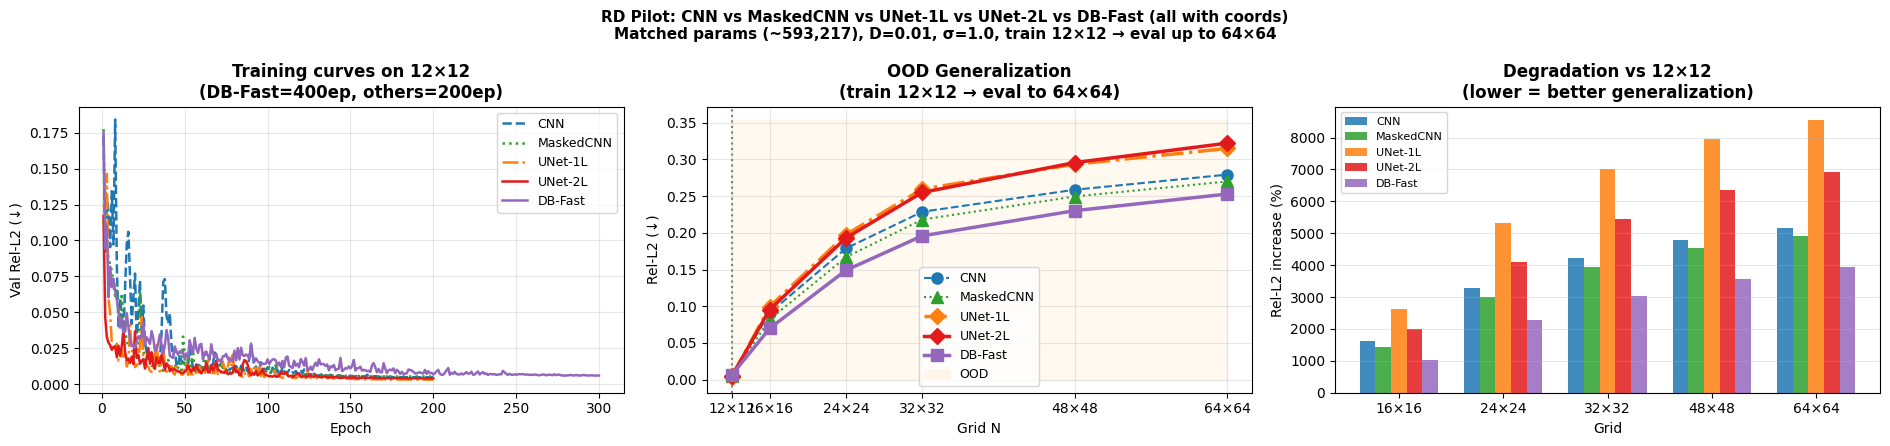

In [ ]:
colors  = {
    'CNN':       '#1f77b4',
    'MaskedCNN': '#2ca02c',
    'UNet-1L':   '#ff7f0e',
    'UNet-2L':   '#e31a1c',   # darker red-orange to contrast with UNet-1L
    'DB-Fast':   '#9467bd',
}
markers = {'CNN':'o','MaskedCNN':'^','UNet-1L':'D','UNet-2L':'D','DB-Fast':'s'}
lstyles = {'CNN':'--','MaskedCNN':':','UNet-1L':'-.','UNet-2L':'-','DB-Fast':'-'}

fig, axes = plt.subplots(1,3,figsize=(19,4.5))

# ── Training curves ──
ax=axes[0]
for name,logs in all_logs:
    ax.plot(logs['epoch'],logs['val_rel_l2'],
            color=colors[name],linestyle=lstyles[name],label=name,lw=1.8)
ax.set_title(f'Training curves on {N_TRAIN}×{N_TRAIN}\n(DB-Fast=400ep, others=200ep)',
             fontweight='bold')
ax.set_xlabel('Epoch'); ax.set_ylabel('Val Rel-L2 (↓)')
ax.legend(fontsize=9); ax.grid(True,alpha=0.3)

# ── Generalization curve ──
ax=axes[1]
for name,_ in models_info:
    vals=[results[name][N] for N in EVAL_GRIDS]
    lw=2.5 if 'UNet' in name or name=='DB-Fast' else 1.5
    ax.plot(EVAL_GRIDS,vals,color=colors[name],linestyle=lstyles[name],
            marker=markers[name],label=name,lw=lw,ms=8)
ax.axvline(x=N_TRAIN,color='gray',linestyle=':',lw=1.5)
ymax=max(results[n][N] for n,_ in models_info for N in EVAL_GRIDS)*1.1
ax.fill_betweenx([0,ymax],N_TRAIN,max(EVAL_GRIDS),alpha=0.06,color='orange',label='OOD')
ax.set_title(f'OOD Generalization\n(train {N_TRAIN}×{N_TRAIN} → eval to {max(EVAL_GRIDS)}×{max(EVAL_GRIDS)})',
             fontweight='bold')
ax.set_xlabel('Grid N'); ax.set_ylabel('Rel-L2 (↓)')
ax.set_xticks(EVAL_GRIDS)
ax.set_xticklabels([f'{N}×{N}' for N in EVAL_GRIDS])
ax.legend(fontsize=9); ax.grid(True,alpha=0.3)

# ── Degradation bars ──
ax=axes[2]
ood=[N for N in EVAL_GRIDS if N!=N_TRAIN]
xp=np.arange(len(ood)); w_bar=0.15
offsets=[-2,-1,0,1,2]
for ki,(name,_) in enumerate(models_info):
    degs=[(results[name][N]-results[name][N_TRAIN])/results[name][N_TRAIN]*100
           for N in ood]
    ax.bar(xp+offsets[ki]*w_bar,degs,w_bar,
           label=name,color=colors[name],alpha=0.85)
ax.set_title(f'Degradation vs {N_TRAIN}×{N_TRAIN}\n(lower = better generalization)',
             fontweight='bold')
ax.set_xlabel('Grid'); ax.set_ylabel('Rel-L2 increase (%)')
ax.set_xticks(xp); ax.set_xticklabels([f'{N}×{N}' for N in ood])
ax.legend(fontsize=8); ax.grid(True,alpha=0.3,axis='y')

plt.suptitle(
    f'RD Pilot: CNN vs MaskedCNN vs UNet-1L vs UNet-2L vs DB-Fast (all with coords)\n'
    f'Matched params (~{TARGET:,}), D={D}, σ={SIGMA}, '
    f'train {N_TRAIN}×{N_TRAIN} → eval up to {max(EVAL_GRIDS)}×{max(EVAL_GRIDS)}',
    fontsize=11,fontweight='bold')
plt.tight_layout()
plt.savefig('rd_unet2l_n16.png',dpi=150,bbox_inches='tight')
plt.show()
